📂 正在读取实测样本: rx_jnr-10_X.npy

✅ 大功告成！盲审杀手锏图片已高清保存为: /root/autodl-tmp/validate/0218/Perception/doppler_iq_constellation.png


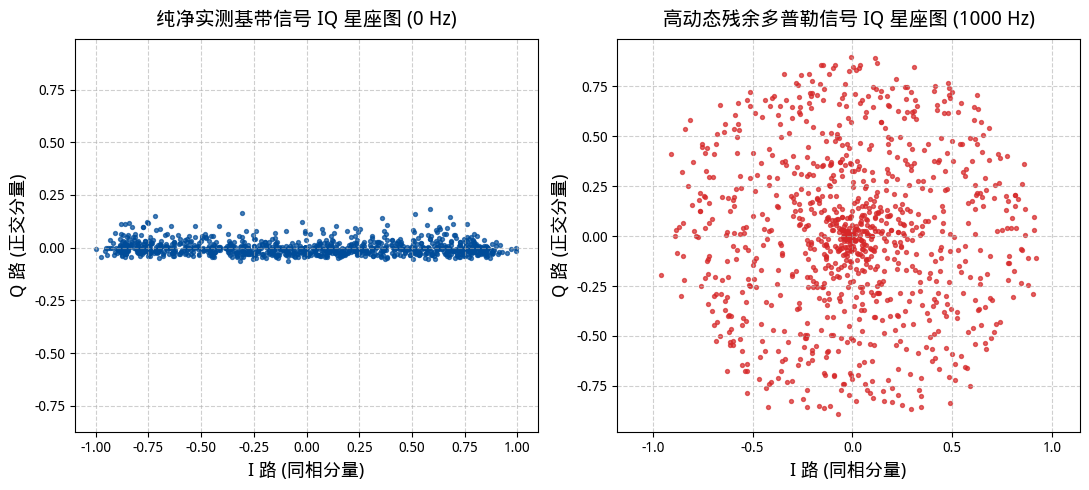

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# ================= 1. 论文中文字体完美支持 =================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return
    except: pass
set_chinese_font()

# ================= 2. 自动寻找实测纯净数据 =================
# 包含两个你之前用过的路径，防报错
data_dir = "/root/autodl-tmp/validate/0218/Perception/dataset_final_ready_v5"
if not os.path.exists(data_dir):
    data_dir = "/root/autodl-tmp/validate/0218/dataset_final_ready_v5"

files = [f for f in os.listdir(data_dir) if f.endswith('_X.npy')]
if not files:
    print("❌ 找不到数据集，请检查目录路径！")
    exit()

# 随便抓取列表里的第一个文件
sample_file = os.path.join(data_dir, files[0])
print(f"📂 正在读取实测样本: {os.path.basename(sample_file)}")

# 加载数据并提取第一帧的 I 路和 Q 路
# x_data 形状为 (N, 1024, 2)，取第 0 个样本
x_data = np.load(sample_file)[0]
I_clean = x_data[:, 0]
Q_clean = x_data[:, 1]

# ================= 3. 物理公式：注入 1000Hz 残余多普勒 =================
fs = 200000.0          # 采样率 200kHz
fd = 1000.0            # 注入 1000Hz 多普勒
t = np.arange(1024) / fs

# 还原为复数进行相位旋转
complex_clean = I_clean + 1j * Q_clean
complex_doppler = complex_clean * np.exp(1j * 2 * np.pi * fd * t)

# 重新拆分出旋转畸变后的 I 路和 Q 路
I_dop = complex_doppler.real
Q_dop = complex_doppler.imag

# ================= 4. 绘制符合学术规范的高清对比图 =================
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# 左图：纯净信号（正常的实测带噪星座点）
axes[0].scatter(I_clean, Q_clean, s=8, alpha=0.7, color='#004C99')
axes[0].set_title('纯净实测基带信号 IQ 星座图 (0 Hz)', fontsize=14, pad=10)
axes[0].set_xlabel('I 路 (同相分量)', fontsize=13)
axes[0].set_ylabel('Q 路 (正交分量)', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axis('equal') # 强制比例 1:1，防止圆形变椭圆

# 右图：多普勒畸变信号（旋转成环状弥散分布）
axes[1].scatter(I_dop, Q_dop, s=8, alpha=0.7, color='#D62728')
axes[1].set_title('高动态残余多普勒信号 IQ 星座图 (1000 Hz)', fontsize=14, pad=10)
axes[1].set_xlabel('I 路 (同相分量)', fontsize=13)
axes[1].set_ylabel('Q 路 (正交分量)', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axis('equal')

# 调整子图间距并保存
plt.tight_layout()
save_path = 'doppler_iq_constellation.png'
plt.savefig(save_path, dpi=600, bbox_inches='tight')
print(f"\n✅ 大功告成！盲审杀手锏图片已高清保存为: {os.path.abspath(save_path)}")